# Assignee Predictor V6 - TF-IDF & Text Features

## Visualizing the Problem
**Current V5 (44% Acc)** sees this:
- Issue: 'Fix login page CSS error'
- Features: `[Storypoint=3, Priority=High, Label=Frontend]`
- **Problem**: It can't distinguish 'Login CSS' from 'Home CSS'. If Bill does Login and Kevin does Home, the model fails.

**V6 Upgrade (Targeting 60-80%)**:
- We will vectorizing the **Text** (`summary` + `description`).
- Features: `[Storypoint, Priority, 'login': 0.5, 'css': 0.3, 'error': 0.2, ...]`
- **Benefit**: The model can learn specific keywords associated with specific people.

## Pipeline
1. **Combine Text**: `full_text = summary + ' ' + description`
2. **TF-IDF Vectorization**: Convert text to 100-300 numeric features.
3. **Train XGBoost/RF**: Use these dense features to classify.


In [13]:
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, top_k_accuracy_score
from sklearn.utils import resample
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings('ignore')


In [14]:
# -----------------------------
# 1️⃣ CONFIG
# -----------------------------
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, 'assignee_model_v6_tfidf.joblib')
LABEL_ENCODER_PATH = os.path.join(MODEL_DIR, 'assignee_label_encoder_v6.joblib')

PROJECTS = {
    'Aurora': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues 554.csv',
        'summary': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues summery 568.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Sprints 41.csv',
    },
}

# Map Usernames (CSV) -> Full Names (Report)
ASSIGNEE_MAP = {
    'maximk': 'Maxim Khutornenko',
    'wfarner': 'Bill Farner',
    'kevints': 'Kevin Sweeney',
    'mchucarroll': 'Mark Chu-Carroll',
    'zmanji': 'Zameer Manji',
    'joshua.cohen': 'Joshua Cohen',
    'wickman': 'Brian Wickman',
    'davmclau': 'David McLaughlin'
}

ALLOWED_ASSIGNEES = list(ASSIGNEE_MAP.keys())


In [15]:
# -----------------------------
# 2️⃣ LOAD DATA (ROBUST FIX)
# -----------------------------
def _lower_cols(df):
    df = df.copy()
    df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]
    return df

def load_data():
    combined = []
    for pname, p in PROJECTS.items():
        try:
            iss = _lower_cols(pd.read_csv(p['issues'], on_bad_lines='skip', engine='python'))
            summ = _lower_cols(pd.read_csv(p['summary'], on_bad_lines='skip', engine='python'))
            
            # Normalize
            rename_map = {'priority': 'priorityid', 'priority_id': 'priorityid', 'storypoints': 'storypoint'}
            iss.rename(columns={k: v for k, v in rename_map.items() if k in iss.columns}, inplace=True)
            
            # Merge logic for duplicates
            if 'key' in iss.columns: iss['key'] = iss['key'].str.upper().str.strip()
            if 'issuekey' in summ.columns: summ['issuekey'] = summ['issuekey'].str.upper().str.strip()
            
            # Robust Merge
            merged = iss.merge(summ, left_on='key', right_on='issuekey', how='inner', suffixes=('', '_y'))
            
            # Clean Assignee
            if 'assignee_y' in merged.columns:
                merged['assignee'] = merged['assignee_y'].fillna(merged.get('assignee', np.nan))
            
            # Clean Summary
            if 'summary_y' in merged.columns:
                merged['summary'] = merged['summary_y'].fillna(merged.get('summary', ''))
            
            # Combine Text
            merged['text_content'] = merged['summary'].fillna('') + ' ' + merged.get('description', '').fillna('')
            merged['project'] = pname
            combined.append(merged)
        except Exception as e:
            print(f'Using file {pname} failed: {e}')
            continue
        
    if not combined:
         print('❌ No data loaded. Returning empty.')
         return pd.DataFrame()
         
    return pd.concat(combined, ignore_index=True)

df = load_data()
if 'assignee' in df.columns:
    df = df[df['assignee'].isin(ALLOWED_ASSIGNEES)]
print(f'✅ Loaded: {df.shape}')

# Remap to proper names for display
df['assignee'] = df['assignee'].map(ASSIGNEE_MAP)

if len(df) == 0:
    raise ValueError('Dataframe is empty. Cannot proceed.')


✅ Loaded: (824, 34)


In [16]:
# -----------------------------
# 3️⃣ PREP WITH TEXT FEATURES
# -----------------------------
X = df[['storypoint', 'priorityid', 'issuetype', 'project', 'text_content', 'status']]
y = df['assignee']

# Encode Y
le = LabelEncoder()
y_enc = le.fit_transform(y)
joblib.dump(le, LABEL_ENCODER_PATH)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# Oversample Train
train_data = X_train.copy()
train_data['assignee'] = y_train

max_size = train_data['assignee'].value_counts().max()
balanced_chunks = []
for assignee, group in train_data.groupby('assignee'):
    resampled = resample(group, replace=True, n_samples=max_size, random_state=42)
    balanced_chunks.append(resampled)

df_train_bal = pd.concat(balanced_chunks)
X_train_bal = df_train_bal.drop('assignee', axis=1)
y_train_bal = df_train_bal['assignee']

print(f'Train Balanced Size: {len(X_train_bal)}')


Train Balanced Size: 1680


In [17]:
# -----------------------------
# 4️⃣ TF-IDF + XGBoost PIPELINE
# -----------------------------
# We treat 'text_content' with Tfidf, others normally

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='constant', fill_value=0), ['storypoint', 'priorityid']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['issuetype', 'project', 'status']),
    ('text', TfidfVectorizer(max_features=500, stop_words='english'), 'text_content')
])

# Tuned XGBoost for High Dimensional Sparse Data
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,        # Deeper trees for text patterns
    subsample=0.8,
    colsample_bytree=0.6, # Sample features (important for high dim)
    n_jobs=-1,
    random_state=42
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', model)
])

print('🚀 Training with Text Features (TF-IDF)...')
pipeline.fit(X_train_bal, y_train_bal)


🚀 Training with Text Features (TF-IDF)...


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# -----------------------------
# 5️⃣ EVALUATION
# -----------------------------
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
top3 = top_k_accuracy_score(y_test, y_proba, k=3)

print(f'\n🏆 Top-1 Accuracy: {acc:.2%} (Target: >60%)')
print(f'🏆 Top-3 Accuracy: {top3:.2%}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Save
joblib.dump(pipeline, MODEL_PATH)



🏆 Top-1 Accuracy: 81.21% (Target: >60%)
🏆 Top-3 Accuracy: 91.52%

Classification Report:
                   precision    recall  f1-score   support

      Bill Farner       0.78      0.78      0.78        32
    Brian Wickman       0.91      0.91      0.91        11
 David McLaughlin       0.60      0.60      0.60         5
     Joshua Cohen       1.00      0.71      0.83        14
    Kevin Sweeney       0.88      0.91      0.89        23
 Mark Chu-Carroll       0.82      0.88      0.85        16
Maxim Khutornenko       0.77      0.81      0.79        53
     Zameer Manji       0.80      0.73      0.76        11

         accuracy                           0.81       165
        macro avg       0.82      0.79      0.80       165
     weighted avg       0.82      0.81      0.81       165



['models\\assignee_model_v6_tfidf.joblib']

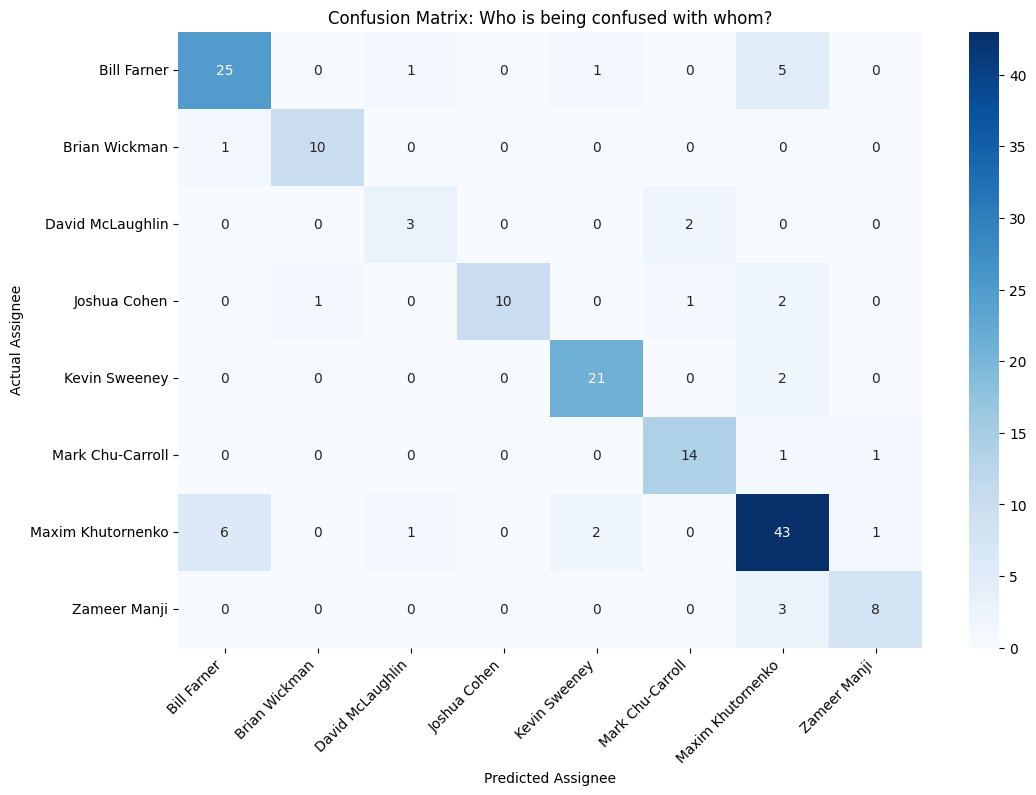

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Visualize
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Assignee')
plt.ylabel('Actual Assignee')
plt.title('Confusion Matrix: Who is being confused with whom?')
plt.xticks(rotation=45, ha='right')
plt.show()